In [2]:
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses, optimizers, callbacks
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置随机种子 (Reproducibility)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2. 读取上一阶段保存的数据
data_path = "../data/modeling_data_ready.pkl"
try:
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
    print("✅ 数据加载成功！")
except FileNotFoundError:
    print("❌ 错误：未找到数据文件，请检查路径。")

X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']

# 同时也读取 SMOTE 数据（用于后续的对比基准模型，SDAE主要用原始数据）
X_train_smote = data['X_train_smote']
y_train_smote = data['y_train_smote']

# 获取输入维度
input_dim = X_train.shape[1]
print(f"输入特征维度: {input_dim}")
print(f"训练集形状: {X_train.shape}")

✅ 数据加载成功！
输入特征维度: 15
训练集形状: (4929, 15)


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# 设置随机种子
tf.random.set_seed(42)
np.random.seed(42)

class SDAEFeatureExtractor:
    """
    堆叠降噪自编码器 (SDAE) 特征提取器。
    支持：
    - 逐层预训练
    - 单类训练模式 (只学正常样本)
    - 深度健康检查 (Dead Neurons check)
    """
    def __init__(self, layer_units=[24, 16, 8], activation='selu', 
                 dropout_rate=0.1, learn_on_class=None):
        """
        :param layer_units: 每一层的神经元数量 list
        :param learn_on_class: 如果设为 0 或 1，则 SDAE 只在该类样本上训练 (One-Class Mode)
        """
        self.layer_units = layer_units
        self.activation = activation
        self.dropout_rate = dropout_rate
        self.learn_on_class = learn_on_class
        self.encoders = []
        self.history = []
        
    def _build_and_train_layer(self, X_train, layer_idx, units):
        input_dim = X_train.shape[1]
        
        # --- 建网 ---
        input_layer = layers.Input(shape=(input_dim,))
        # 降噪：Dropout
        masked = layers.Dropout(self.dropout_rate)(input_layer)
        # 编码：加入 L1 正则化稀疏约束
        encoded = layers.Dense(units, activation=self.activation,
                               activity_regularizer=regularizers.l1(1e-5),
                               name=f"enc_{layer_idx}")(masked)
        # 解码：尝试还原
        decoded = layers.Dense(input_dim, activation='linear')(encoded)
        
        autoencoder = keras.Model(inputs=input_layer, outputs=decoded)
        encoder = keras.Model(inputs=input_layer, outputs=encoded)
        
        autoencoder.compile(optimizer='adam', loss='mse')
        
        # --- 训练 ---
        # Early Stopping 防止过拟合
        es = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        
        print(f"  [SDAE] Layer {layer_idx+1} Training ({input_dim}->{units})...", end="")
        hist = autoencoder.fit(X_train, X_train, 
                               epochs=50, batch_size=64, 
                               validation_split=0.1, verbose=0,
                               callbacks=[es])
        print(f" Done. Loss: {hist.history['loss'][-1]:.4f}")
        
        return encoder, hist

    def fit(self, X, y=None):
        """逐层训练"""
        self.encoders = []
        
        # 数据筛选策略：如果是 One-Class 模式，只选特定样本训练 AE
        train_data = X
        if self.learn_on_class is not None and y is not None:
            print(f">>> SDAE 仅在 Label={self.learn_on_class} 的样本上进行学习 (One-Class 模式)")
            train_data = X[y == self.learn_on_class]
        
        current_input = train_data
        
        for i, units in enumerate(self.layer_units):
            encoder, _ = self._build_and_train_layer(current_input, i, units)
            self.encoders.append(encoder)
            # 下一层的输入是这一层的输出
            current_input = encoder.predict(current_input, verbose=0)
            
        return self

    def transform_all_layers(self, X):
        """返回每一层的特征，格式：{layer_idx: feature_matrix}"""
        features = {}
        curr = X
        for i, enc in enumerate(self.encoders):
            curr = enc.predict(curr, verbose=0)
            features[i] = curr
        return features
    
    def diagnose(self, X_sample):
        """检查是否有死神经元"""
        print("\n--- SDAE 深度体检 ---")
        curr = X_sample
        for i, enc in enumerate(self.encoders):
            curr = enc.predict(curr, verbose=0)
            vars = np.var(curr, axis=0)
            dead_count = np.sum(vars < 1e-4)
            status = "⚠️ 坍塌" if dead_count > enc.output_shape[1]/2 else "✅ 健康"
            print(f"Layer {i+1}: Dead Neurons = {dead_count}/{enc.output_shape[1]} | {status}")


class CSDEClassifier(BaseEstimator, ClassifierMixin):
    """
    CSDE 集成策略类。
    即插即拔：可以更换 base_estimator (LR, SVM, etc.)
    """
    def __init__(self, sdae_extractor, base_estimator=None, n_bags=5):
        self.sdae = sdae_extractor
        self.n_bags = n_bags
        # 默认基分类器是 逻辑回归 (验证“简单模型”假设)
        self.base_estimator = base_estimator if base_estimator else LogisticRegression(solver='liblinear', C=1.0)
        self.models_ = [] # 存储所有子模型: {'model': clf, 'layer': int, 'bag': int}

    def fit(self, X, y):
        # 1. 确保 SDAE 已经训练好，如果没有则训练
        if not self.sdae.encoders:
            print("检测到 SDAE 未训练，开始训练特征提取器...")
            self.sdae.fit(X, y)
            
        self.models_ = []
        X_maj = X[y == 0]
        X_min = X[y == 1]
        
        print(f"\n>>> 开始 CSDE 集成训练 (Bags={self.n_bags})...")
        
        # 预先计算所有数据在每一层的特征，避免重复计算 (极大加速)
        # features_cache[layer_idx] = transformed_X
        print("  正在预计算所有层级特征...")
        layer_features_map = self.sdae.transform_all_layers(X)
        
        for bag in range(self.n_bags):
            # --- Bagging: 下采样多数类 ---
            # 这里的 random_state=bag 保证每个包的数据不同
            X_maj_sample = shuffle(X_maj, random_state=bag)[:len(X_min)]
            
            # 获取本次 Bag 的索引
            # 注意：这里需要一点技巧来对应回原始 X 的索引，
            # 为简单起见，我们重新拼接数据，但直接使用预计算好的特征
            
            # 构建本次 Bag 的数据结构
            # 多数类样本数 = 少数类样本数
            n_samples = len(X_min) * 2
            y_bag = np.concatenate([np.zeros(len(X_min)), np.ones(len(X_min))])
            
            # 针对每一层训练一个基分类器
            for layer_idx, X_layer_all in layer_features_map.items():
                # 这里的 X_layer_all 是全量数据的特征
                # 我们需要提取出 X_maj_sample 和 X_min 对应的特征
                # 为了代码简洁，这里我们重新对全量特征做一次 mask 提取
                
                # 这种写法稍微低效但逻辑最清晰：
                feat_maj = X_layer_all[y==0]
                feat_min = X_layer_all[y==1]
                
                feat_maj_sample = shuffle(feat_maj, random_state=bag)[:len(feat_min)]
                
                X_train_bag = np.concatenate([feat_maj_sample, feat_min])
                X_train_bag, y_train_bag = shuffle(X_train_bag, y_bag, random_state=bag)
                
                # 训练基分类器
                clf = clone(self.base_estimator)
                clf.fit(X_train_bag, y_train_bag)
                
                self.models_.append({
                    'model': clf,
                    'layer_idx': layer_idx,
                    'bag_idx': bag
                })
                
        print(f"✅ 集成完毕，共训练 {len(self.models_)} 个基模型。")
        return self

    def predict_proba(self, X):
        # 1. 预计算测试集特征
        layer_features_map = self.sdae.transform_all_layers(X)
        
        # 2. 累加预测
        y_pred_total = np.zeros(len(X))
        
        for item in self.models_:
            layer_idx = item['layer_idx']
            clf = item['model']
            
            # 获取对应层的特征
            features = layer_features_map[layer_idx]
            pred = clf.predict_proba(features)[:, 1]
            y_pred_total += pred
            
        # 3. 平均
        return y_pred_total / len(self.models_)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) > threshold).astype(int)


class ExperimentLab:
    """
    实验管理类：负责运行 Baseline，评估 CSDE，画图
    """
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        
    def run_baseline(self):
        print("\n=== Running Baselines (Raw Features) ===")
        models = {
            "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=1000),
            "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=10),
            "LightGBM": lgb.LGBMClassifier(class_weight='balanced', verbose=-1),
            # CatBoost 需要 verbose=0 否则刷屏
            "CatBoost": CatBoostClassifier(auto_class_weights='Balanced', verbose=0) 
        }
        
        results = {}
        for name, model in models.items():
            model.fit(self.X_train, self.y_train)
            pred = model.predict_proba(self.X_test)[:, 1]
            auc = roc_auc_score(self.y_test, pred)
            results[name] = auc
            print(f"  {name:<20} | AUC: {auc:.4f}")
        return results

    def evaluate_csde(self, model, title="CSDE"):
        print(f"\n=== Evaluating {title} ===")
        pred_proba = model.predict_proba(self.X_test)
        auc = roc_auc_score(self.y_test, pred_proba)
        print(f"  Total AUC: {auc:.4f}")
        return auc
    
    def probe_layers(self, sdae_extractor):
        """线性探针：检查每一层特征是否越来越容易被线性分割"""
        print("\n=== Layer-wise Linear Probing ===")
        features = sdae_extractor.transform_all_layers(self.X_train)
        test_features = sdae_extractor.transform_all_layers(self.X_test)
        
        for layer_idx, X_tr in features.items():
            X_te = test_features[layer_idx]
            
            # 使用简单的线性分类器探测
            probe = LogisticRegression(class_weight='balanced', solver='liblinear')
            probe.fit(X_tr, self.y_train)
            score = roc_auc_score(self.y_test, probe.predict_proba(X_te)[:, 1])
            
            print(f"  Layer {layer_idx+1} Feature AUC: {score:.4f}")

e:\miniconda3\envs\GradProject\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
# ==========================================
# 0. 数据准备
# ==========================================
# 假设 X_train, X_test 等已经加载
# 务必归一化！SDAE 对数值敏感
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 初始化实验室
lab = ExperimentLab(X_train_scaled, y_train, X_test_scaled, y_test)

# ==========================================
# 1. 运行 Baseline (确立基准线)
# ==========================================
# 看看不搞花里胡哨的，直接上 XGBoost 能跑多少分
baseline_scores = lab.run_baseline()
xgb_score = baseline_scores['XGBoost']

# ==========================================
# 2. 实验配置 A: 标准 SDAE + LR (无监督预训练)
# ==========================================
print("\n>>>>>>>>>> 实验 A: 标准 SDAE (全样本训练) >>>>>>>>>>")
sdae_std = SDAEFeatureExtractor(
    layer_units=[24, 12, 6], 
    activation='selu',     # selu 自带归一化性质，防止死神经元
    learn_on_class=None    # None 表示使用所有数据进行重构训练
)

csde_std = CSDEClassifier(
    sdae_extractor=sdae_std, 
    base_estimator=LogisticRegression(solver='liblinear'), # 简单的基分类器
    n_bags=5 # 广度
)

csde_std.fit(X_train_scaled, y_train)
sdae_std.diagnose(X_test_scaled) # 看看神经元死没死
score_a = lab.evaluate_csde(csde_std, title="Standard CSDE")


# ==========================================
# 3. 实验配置 B: One-Class SDAE + LR (你的核心假设)
# ==========================================
# 假设：只让 SDAE 学习“正常人”(Label 0)，欺诈者经过网络会被扭曲，特征分布差异变大
print("\n>>>>>>>>>> 实验 B: One-Class SDAE (只学正常样本) >>>>>>>>>>")
sdae_oc = SDAEFeatureExtractor(
    layer_units=[32, 16, 8], # 可以尝试更深的结构
    activation='selu',
    learn_on_class=0       # <--- 关键修改：只在 Label 0 上训练 Autoencoder
)

csde_oc = CSDEClassifier(
    sdae_extractor=sdae_oc,
    base_estimator=LogisticRegression(C=0.5), # 稍微加点正则
    n_bags=10 # 增加广度
)

csde_oc.fit(X_train_scaled, y_train)
score_b = lab.evaluate_csde(csde_oc, title="One-Class CSDE")

# ==========================================
# 4. 探针分析与对比
# ==========================================
print("\n=== 最终结果汇总 ===")
print(f"Baseline (XGBoost): {xgb_score:.4f}")
print(f"Method A (Std):     {score_a:.4f}")
print(f"Method B (OneCls):  {score_b:.4f}")

# 看看 Method B 的每一层特征是否真的变好了
lab.probe_layers(sdae_oc)


=== Running Baselines (Raw Features) ===
  LogisticRegression   | AUC: 0.8556


e:\miniconda3\envs\GradProject\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:16:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  XGBoost              | AUC: 0.8328


e:\miniconda3\envs\GradProject\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM             | AUC: 0.8441
  CatBoost             | AUC: 0.8509

>>>>>>>>>> 实验 A: 标准 SDAE (全样本训练) >>>>>>>>>>
检测到 SDAE 未训练，开始训练特征提取器...
  [SDAE] Layer 1 Training (15->24)... Done. Loss: 0.0325
  [SDAE] Layer 2 Training (24->12)... Done. Loss: 0.0110
  [SDAE] Layer 3 Training (12->6)... Done. Loss: 0.0384

>>> 开始 CSDE 集成训练 (Bags=5)...
  正在预计算所有层级特征...
✅ 集成完毕，共训练 15 个基模型。

--- SDAE 深度体检 ---
Layer 1: Dead Neurons = 0/24 | ✅ 健康
Layer 2: Dead Neurons = 0/12 | ✅ 健康
Layer 3: Dead Neurons = 0/6 | ✅ 健康

=== Evaluating Standard CSDE ===
  Total AUC: 0.8449

>>>>>>>>>> 实验 B: One-Class SDAE (只学正常样本) >>>>>>>>>>
检测到 SDAE 未训练，开始训练特征提取器...
>>> SDAE 仅在 Label=0 的样本上进行学习 (One-Class 模式)
  [SDAE] Layer 1 Training (15->32)... Done. Loss: 0.0337
  [SDAE] Layer 2 Training (32->16)... Done. Loss: 0.0082
  [SDAE] Layer 3 Training (16->8)... Done. Loss: 0.0259

>>> 开始 CSDE 集成训练 (Bags=10)...
  正在预计算所有层级特征...
✅ 集成完毕，共训练 30 个基模型。

=== Evaluating One-Class CSDE ===
  Total AUC: 0.8523

=== 最终结果汇总 ===
Baseli


=== Baseline (LR) ===
Baseline AUC: 0.85547

=== Training Residual SDAE ===
>>> [One-Class] 训练集: 3621 正常样本

>>> 开始逐层预训练...
  Layer 1: Input 15 -> Output 24
  Layer 2: Input 24 -> Output 12
  Layer 3: Input 12 -> Output 6
>>> 训练完成。

=== Extracting Features ===
Augmented Shape: (4929, 22)

=== Final LR on Augmented Features ===
----------------------------------------
Baseline AUC: 0.85547
Method C AUC: 0.85534
----------------------------------------


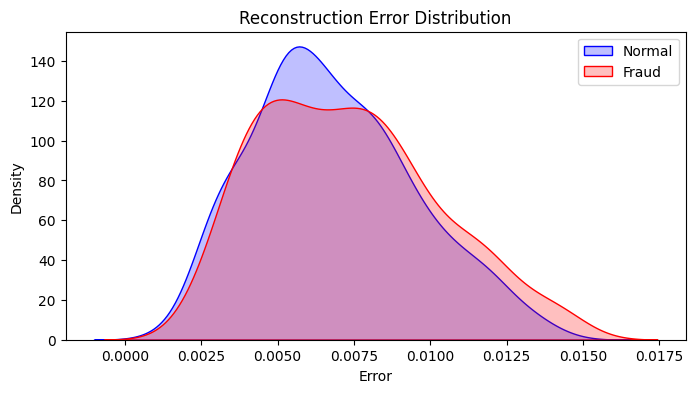

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks, Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import MinMaxScaler

# 清理之前的 Keras 图，防止层名冲突 (input_layer_7 etc.)
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

class ResidualSDAE:
    def __init__(self, layer_units=[24, 12, 6], activation='selu', dropout_rate=0.1):
        self.layer_units = layer_units
        self.activation = activation
        self.dropout_rate = dropout_rate
        self.encoders = []
        self.first_autoencoder = None 
        
    def fit(self, X, y=None):
        # 0. 初始化
        self.encoders = [] # 确保列表被清空
        keras.backend.clear_session() # 清理内存中的旧模型
        
        # 确保数据是 float32 类型的 numpy 数组
        X_curr = np.array(X, dtype=np.float32)
        
        # 1. One-Class 筛选
        if y is not None:
            X_train_subset = X_curr[y == 0]
            print(f">>> [One-Class] 训练集: {X_train_subset.shape[0]} 正常样本")
        else:
            X_train_subset = X_curr
            
        current_input = X_train_subset
        
        # 2. 逐层预训练
        print("\n>>> 开始逐层预训练...")
        for i, units in enumerate(self.layer_units):
            input_dim = current_input.shape[1]
            print(f"  Layer {i+1}: Input {input_dim} -> Output {units}")
            
            # --- 建网 ---
            input_layer = layers.Input(shape=(input_dim,))
            masked = layers.Dropout(self.dropout_rate)(input_layer)
            
            encoded = layers.Dense(units, activation=self.activation,
                                   activity_regularizer=regularizers.l1(1e-5))(masked)
            
            decoded = layers.Dense(input_dim, activation='linear')(encoded)
            
            autoencoder = Model(inputs=input_layer, outputs=decoded)
            encoder = Model(inputs=input_layer, outputs=encoded)
            
            autoencoder.compile(optimizer='adam', loss='mse')
            
            # --- 训练 ---
            es = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
            autoencoder.fit(current_input, current_input, 
                            epochs=40, batch_size=64, 
                            validation_split=0.1, verbose=0, callbacks=[es])
            
            # --- 保存 ---
            self.encoders.append(encoder)
            if i == 0:
                self.first_autoencoder = autoencoder
            
            # --- 关键：更新下一层的输入 ---
            # 显式转换为 numpy，防止 Tensor 引用链导致的维度推断错误
            current_input = encoder.predict(current_input, verbose=0)
            
        print(">>> 训练完成。")
        return self

    def transform(self, X):
        """
        生成增强特征: [原始特征, 隐层特征, 重构误差]
        """
        # 强制转换为 numpy float32
        X_in = np.array(X, dtype=np.float32)
        
        # 1. 隐层特征 (Deep Latent)
        feat_latent = X_in
        
        # 逐层传递，并打印维度变化以便调试
        # print("Debug Transform Shapes:")
        # print(f"  Input: {feat_latent.shape}")
        
        for idx, enc in enumerate(self.encoders):
            feat_latent = enc.predict(feat_latent, verbose=0)
            # print(f"  After Layer {idx+1}: {feat_latent.shape}")
            
        # 2. 重构误差 (Anomaly Score) - 仅使用第一层
        X_recon = self.first_autoencoder.predict(X_in, verbose=0)
        feat_error = np.mean(np.square(X_in - X_recon), axis=1).reshape(-1, 1)
        
        # 3. 拼接
        # [Original (15), Latent (6), Error (1)] -> Total 22
        X_augmented = np.hstack([X_in, feat_latent, feat_error])
        
        return X_augmented, feat_error

# ==========================================
# 测试运行
# ==========================================

# 1. 准备数据 (务必归一化)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. 训练 Baseline
print("=== Baseline (LR) ===")
lr_base = LogisticRegression(class_weight='balanced', solver='liblinear')
lr_base.fit(X_train_scaled, y_train)
base_auc = roc_auc_score(y_test, lr_base.predict_proba(X_test_scaled)[:, 1])
print(f"Baseline AUC: {base_auc:.5f}")

# 3. 训练 Residual SDAE
print("\n=== Training Residual SDAE ===")
# 维度设置: 15 -> 24 -> 12 -> 6
rsdae = ResidualSDAE(layer_units=[24, 12, 6], activation='selu')
rsdae.fit(X_train_scaled, y_train)

# 4. 转换特征
print("\n=== Extracting Features ===")
X_train_aug, _ = rsdae.transform(X_train_scaled)
X_test_aug, test_error = rsdae.transform(X_test_scaled)
print(f"Augmented Shape: {X_train_aug.shape}")

# 5. 训练最终模型
print("\n=== Final LR on Augmented Features ===")
lr_final = LogisticRegression(class_weight='balanced', solver='liblinear')
lr_final.fit(X_train_aug, y_train)

pred_final = lr_final.predict_proba(X_test_aug)[:, 1]
final_auc = roc_auc_score(y_test, pred_final)

print("-" * 40)
print(f"Baseline AUC: {base_auc:.5f}")
print(f"Method C AUC: {final_auc:.5f}")
print("-" * 40)

# 6. 画图验证误差分布
plt.figure(figsize=(8, 4))
df_err = pd.DataFrame({'Error': test_error.flatten(), 'Label': y_test})
# 去除极值画图更清晰
limit = np.percentile(df_err['Error'], 98) 
df_plot = df_err[df_err['Error'] < limit]

sns.kdeplot(data=df_plot[df_plot['Label']==0], x='Error', fill=True, label='Normal', color='blue')
sns.kdeplot(data=df_plot[df_plot['Label']==1], x='Error', fill=True, label='Fraud', color='red')
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()


=== ⚡ 执行极限压缩测试 ⚡ ===
>>> [One-Class] 训练集: 3621 正常样本

>>> 开始逐层预训练...
  Layer 1: Input 15 -> Output 8
  Layer 2: Input 8 -> Output 4
>>> 训练完成。

Baseline AUC: 0.85547
Extreme  AUC: 0.85485


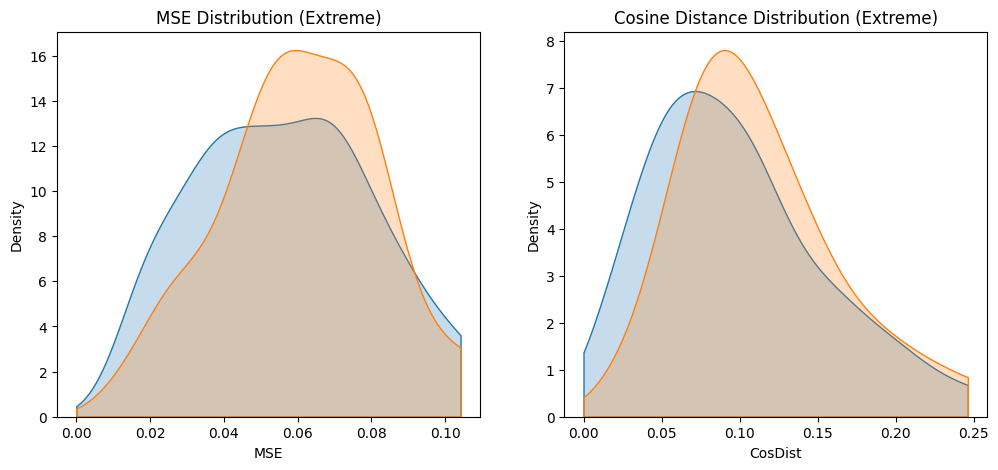

In [6]:
# ==========================================
# 极限测试：高强度压缩 + 高噪声
# ==========================================

from sklearn.metrics.pairwise import cosine_similarity

class StrangledSDAE(ResidualSDAE):
    def transform(self, X):
        X_in = np.array(X, dtype=np.float32)
        
        # 1. 隐层特征
        feat_latent = X_in
        for enc in self.encoders:
            feat_latent = enc.predict(feat_latent, verbose=0)
            
        # 2. 重构 (使用第一层)
        X_recon = self.first_autoencoder.predict(X_in, verbose=0)
        
        # --- 改进点：双重异常检测 ---
        
        # A. MSE (原有指标)
        mse = np.mean(np.square(X_in - X_recon), axis=1).reshape(-1, 1)
        
        # B. Cosine Similarity (新指标：方向一致性)
        # Cosine 越接近 1 越好，所以异常分 = 1 - Cosine
        # 注意：需要逐行计算，sklearn 的 cosine_similarity 是矩阵对矩阵
        # 这里手写一个简单的行向量余弦计算
        def cosine_sim_rows(a, b):
            norm_a = np.linalg.norm(a, axis=1)
            norm_b = np.linalg.norm(b, axis=1)
            dot = np.sum(a * b, axis=1)
            # 防止除零
            return dot / (norm_a * norm_b + 1e-10)
            
        cos_sim = cosine_sim_rows(X_in, X_recon).reshape(-1, 1)
        cos_dist = 1.0 - cos_sim # 转换成距离，越大越异常
        
        # 3. 拼接: [原始, 隐层, MSE, Cosine距离]
        X_augmented = np.hstack([X_in, feat_latent, mse, cos_dist])
        
        # 返回增强特征 和 两种误差用于画图
        return X_augmented, mse, cos_dist

# --- 重新运行实验 ---

print("\n=== ⚡ 执行极限压缩测试 ⚡ ===")

# 1. 实例化：注意这里 dropout=0.5，且层数极少
# 15 -> 8 -> 4 (极度压缩)
s_sdae = StrangledSDAE(layer_units=[8, 4], activation='tanh', dropout_rate=0.4)

# 2. 训练
s_sdae.fit(X_train_scaled, y_train)

# 3. 提取
X_train_aug, _, _ = s_sdae.transform(X_train_scaled)
X_test_aug, test_mse, test_cos = s_sdae.transform(X_test_scaled)

# 4. 评估
lr_extreme = LogisticRegression(class_weight='balanced', solver='liblinear')
lr_extreme.fit(X_train_aug, y_train)
auc_extreme = roc_auc_score(y_test, lr_extreme.predict_proba(X_test_aug)[:, 1])

print(f"\nBaseline AUC: {base_auc:.5f}")
print(f"Extreme  AUC: {auc_extreme:.5f}")

# 5. 画新图：看看 Cosine Distance 是否分开了？
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df_mse = pd.DataFrame({'MSE': test_mse.flatten(), 'Label': y_test})
limit_mse = np.percentile(df_mse['MSE'], 95)
sns.kdeplot(data=df_mse[df_mse['Label']==0], x='MSE', fill=True, clip=(0, limit_mse), label='Normal')
sns.kdeplot(data=df_mse[df_mse['Label']==1], x='MSE', fill=True, clip=(0, limit_mse), label='Fraud')
plt.title("MSE Distribution (Extreme)")

plt.subplot(1, 2, 2)
df_cos = pd.DataFrame({'CosDist': test_cos.flatten(), 'Label': y_test})
# Cosine 距离通常在 0~0.5 之间
limit_cos = np.percentile(df_cos['CosDist'], 95)
sns.kdeplot(data=df_cos[df_cos['Label']==0], x='CosDist', fill=True, clip=(0, limit_cos), label='Normal')
sns.kdeplot(data=df_cos[df_cos['Label']==1], x='CosDist', fill=True, clip=(0, limit_cos), label='Fraud')
plt.title("Cosine Distance Distribution (Extreme)")

plt.show()